In [22]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.ops as ops
import math
import cv2
import ast


import glob
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.nn import TransformerEncoder, TransformerEncoderLayer
import torchvision
import torchvision.models as models
import torchvision.datasets as datasets

In [23]:
H_SHAPE = 768
W_SHAPE = 512

In [24]:
class Resnet_FPN_split(nn.Module):
    def __init__(self,out_channels = 128):
        super(Resnet_FPN_split, self).__init__()
        self.resnet = models.resnet18(pretrained=False)
        self.resnet.to(device)
        self.layer_1 = nn.Sequential(*list(self.resnet.children())[:4])
        self.layer_2 = self.resnet.layer2
        self.layer_3 = self.resnet.layer3
        self.layer_4 = self.resnet.layer4

        self.lateral4 = nn.Conv2d(512, out_channels, kernel_size=1, stride=1, padding=0)
        self.lateral3 = nn.Conv2d(256, out_channels, kernel_size=1, stride=1, padding=0)
        self.lateral2 = nn.Conv2d(128, out_channels, kernel_size=1, stride=1, padding=0)
        self.lateral1 = nn.Conv2d(64, out_channels, kernel_size=1, stride=1, padding=0)

        self.output4 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.output3 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.output2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.output1 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        if (torch.isnan(x).any()):
            print("error at Resnet_FPN")
        c1 = self.layer_1(x)
        if (torch.any(torch.isnan(c1))):
            print('error resnet ')
        c2 = self.layer_2(c1)
        c3 = self.layer_3(c2)
        c4 = self.layer_4(c3)

        p4 = self.lateral4(c4)
        p3 = self.lateral3(c3) + F.interpolate(p4, scale_factor=2, mode='nearest')
        p2 = self.lateral2(c2) + F.interpolate(p3, scale_factor=2, mode='nearest')
        p1 = self.lateral1(c1) + F.interpolate(p2, scale_factor=2, mode='nearest')

        p4 = self.output4(p4)
        p3 = self.output3(p3)
        p2 = self.output2(p2)
        p1 = self.output1(p1)

        return p1, p2, p3, p4

In [25]:
class transferlayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(transferlayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
    def forward(self, x):
        x = self.conv(x)
        return x

In [26]:
      
class sun_branch_1(nn.Module):
    def __init__(self, size_):
        super(sun_branch_1, self).__init__()
        self.size_ = size_
        self.Max = nn.MaxPool2d(kernel_size=size_, stride=size_ , padding= (0,0))
        self.Conv = nn.Conv2d(64, 32, kernel_size=3, stride=1, padding= 1)
        self.relu = nn.ReLU()
    def forward(self, x , input_channel):
        x = x.clone()
        x = self.Max(x)
        x = self.Conv(x)
        x = self.relu(x)
        return x

class sun_branch_2(nn.Module):
    def __init__(self, size_):
        super(sun_branch_2, self).__init__()
        self.size_ = size_
        self.Max = nn.MaxPool2d(kernel_size=size_, stride=size_ , padding= (0,0))
        self.Conv = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding= 1)
        self.relu = nn.ReLU()
    def forward(self, x , input_channel):
        x = x.clone()
        x = self.Max(x)
        x = self.Conv(x)
        x = self.relu(x)
        return x

class sun_branch_3(nn.Module):
    def __init__(self, size_):
        super(sun_branch_3, self).__init__()
        self.size_ = size_
        self.Max = nn.MaxPool2d(kernel_size=size_, stride=size_ , padding= (0,0))
        self.Conv = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding= 1)
        self.relu = nn.ReLU()
    def forward(self, x , input_channel):
        x = x.clone()
        x = self.Max(x)
        x = self.Conv(x)
        x = self.relu(x)
        return x

class updasample_combines(nn.Module):
    def __init__(self ):
        super(updasample_combines, self).__init__()
        self.conv = nn.Conv2d(32, 256, kernel_size=3, stride=1, padding= 'same')
        self.bn = nn.BatchNorm2d(256)
        self.relu = nn.ReLU()
    def forward(self, x_tensor):
        x = F.interpolate(x_tensor, size =(H_SHAPE,W_SHAPE), mode='bilinear', align_corners=False)
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

class predict_row(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(predict_row, self).__init__()
        self.conv = nn.Conv2d(in_channels, 1, kernel_size=1, stride=1, padding=0)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        row_ = self.conv(x)
        final_row = self.sigmoid(row_)
        return final_row
class predict_col(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(predict_col, self).__init__()
        self.conv = nn.Conv2d(in_channels, 1, kernel_size=1, stride=1, padding=0)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        col_ = self.conv(x)
        final_col = self.sigmoid(col_)
        return final_col

In [27]:
class NewMessPassingW(nn.Module):  # L -> R Message Passing
    def __init__(self, in_channels=32, out_channels=32, width=16):
        super(NewMessPassingW, self).__init__()
        
        self.width = width  # Store width for reshaping later
        
        # Each slice along width gets a unique kernel using grouped convolutions
        self.l2r_conv = nn.Conv2d(in_channels * width, out_channels * width, 
                                  kernel_size=(9, 1), stride=1, padding=(4, 0), 
                                  groups=width, bias=False)
        encoder_layer = TransformerEncoderLayer(d_model=6144, nhead=8)
        self.transformer = TransformerEncoder(encoder_layer, num_layers=3)
    def forward(self, x):
        B, C, H, W = x.shape  # Batch, Channels, Height, Width
        
        # Reshape to merge width into the channel dimension
        x = x.permute(0, 3, 1, 2).reshape(B, C * W, H, 1)  # (B, C*W, H, 1)
        
        # Apply grouped convolution (each slice gets its own kernel)
        x = self.l2r_conv(x)
        x = x.reshape(B, W, -1) 
        x = self.transformer(x)
        x = x.reshape(B, W, C, H).permute(0, 2, 3, 1)
        
        return x

In [28]:
class NewMessPassingH(nn.Module):  # T -> B Message Passing
    def __init__(self, in_channels=32, out_channels=32, height=12):
        super(NewMessPassingH, self).__init__()
        
        self.height = height  # Store height for reshaping later
        
        # Each slice along height gets a unique kernel using grouped convolutions
        self.t2b_conv = nn.Conv2d(in_channels * height, out_channels * height, 
                                  kernel_size=(1, 9), stride=1, padding=(0, 4), 
                                  groups=height, bias=False)
        encoder_layer = TransformerEncoderLayer(d_model=4096, nhead=8)
        self.transformer = TransformerEncoder(encoder_layer, num_layers=3)
    def forward(self, x):
        B, C, H, W = x.shape  # Batch, Channels, Height, Width
        
        # Reshape to merge height into the channel dimension
        x = x.permute(0, 2, 1, 3).reshape(B, C * H, W, 1)  # (B, C*H, W, 1)
        
        # Apply grouped convolution (each slice gets its own kernel)
        x = self.t2b_conv(x)
        x = x.reshape(B, H, -1)
        x = self.transformer(x)
        x = x.reshape(B, H, C, W).permute(0, 2, 1, 3)  # (B, C, H, W)
        # Reshape back to original shape
        # x = x.reshape(B, H, C, W).permute(0, 2, 1, 3)  # (B, C, H, W)
        
        return x

In [29]:
class model_split(nn.Module):
    def __init__(self):
        super(model_split, self).__init__()
        self.backbone = Resnet_FPN_split()
        self.sun_branch_W_1 = sun_branch_1(size_=(1,2))
        self.sun_branch_W_2 = sun_branch_2(size_=(1,2))
        self.sun_branch_W_3 = sun_branch_3(size_=(1,2))

        self.sun_branch_H_1 = sun_branch_1(size_=(2,1))
        self.sun_branch_H_2 = sun_branch_2(size_=(2,1))
        self.sun_branch_H_3 = sun_branch_3(size_=(2,1))
        self.transfer_layer = transferlayer(128, 64) 
        self.predict_row = predict_row(256, 1)
        self.predict_col = predict_col(256, 1)
        self.updasample_combines_H = updasample_combines()
        self.updasample_combines_W = updasample_combines()

        self.NewMessPassingH = NewMessPassingH(32,32,24)
        self.NewMessPassingW = NewMessPassingW(32,32)
    def forward(self, x):
        c2, c3 , c4, c5 = self.backbone(x)
        fm = self.transfer_layer(c2)
        x_H = fm
        x_W = fm
        # for _ in range(3):
        x_H= self.sun_branch_H_1(x_H, x_H.shape[1])
        x_H= self.sun_branch_H_2(x_H, x_H.shape[1])
        x_H= self.sun_branch_H_3(x_H, x_H.shape[1])

        x_W = self.sun_branch_W_1(x_W, x_W.shape[1])
        x_W = self.sun_branch_W_2(x_W, x_W.shape[1])
        x_W = self.sun_branch_W_3(x_W, x_W.shape[1])
        print(f'x_H shape {x_H.shape}') 
        print(f'x_W shape {x_W.shape}')
        col_feature = self.NewMessPassingH(x_H)
        row_feature = self.NewMessPassingW(x_W)

        col_feature = self.updasample_combines_H(col_feature)
        row_feature = self.updasample_combines_W(row_feature)

        final_row = self.predict_row(row_feature)
        final_col = self.predict_col(col_feature)
        return final_row, final_col        

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [31]:
# H_SHAPE = 768
# W_SHAPE = 512

# x = torch.randn(1, 3, H_SHAPE, W_SHAPE).to(device)
# model_split.eval()
# with torch.no_grad():
#     row, col = model_split(x)
#     print(row.shape, col.shape)

In [32]:
# x_test = torch.randn(1, 3, 768,128)
# in_channels=32
# out_channels=32
# height=12
# t2b_conv = nn.Conv2d(in_channels * height, out_channels * height, 
#                                   kernel_size=(1, 9), stride=1, padding=(0, 4), 
#                                   groups=height, bias=False)

In [33]:
import ast
def convert_String_to_array(string_array):
    nested_list = ast.literal_eval(string_array)

    numpy_array_1 = np.array(nested_list[0])
    numpy_array_2 = np.array(nested_list[1])
    # print(numpy_array_1.shape)
    # print(numpy_array_2.shape)
    # numpy_array = np.concatenate((numpy_array_1, numpy_array_2), axis=0)
    return numpy_array_1 , numpy_array_2

def normalize_img(img):
    #norm_img = (img - img.min()) / (img.max() - img.min())
    norm_img = np.array(img,dtype= np.float32)/255.0
    return norm_img

def make_image_row(row ,h , w,  new_shape= (512,512)):
    img_row = np.zeros((h, w), dtype=np.uint8)
    mask_img_row = np.where(row ==1 )
    img_row[mask_img_row,:] = 1
    img_row = cv2.resize(img_row, new_shape)
    img_row  = np.array(img_row)
    return img_row

def make_image_col(col,h , w, new_shape= (512,512)):
    img_col = np.zeros((h, w), dtype=np.uint8)
    mask_img_col = np.where(col ==1 )
    img_col[:,mask_img_col] = 1
    img_col = cv2.resize(img_col, new_shape)
    img_col  = np.array(img_col)
    return img_col

In [34]:
class Data_loader(Dataset):
    def __init__(self, data_frame):
        self.data = data_frame
    def __len__(self):
        return len(self.data)
    def make_image_col(self, col, h, w, new_shape= (512,512)):
        img_col = np.zeros((h, w), dtype=np.uint8)
        mask_img_col = np.where(col ==1 )
        img_col[:,mask_img_col] = 1
        img_col = cv2.resize(img_col, new_shape)
        img_col  = np.array(img_col)
        return img_col

    def make_image_row(self, row, h, w, new_shape= (512,512)):
        img_row = np.zeros((h, w), dtype=np.uint8)
        mask_img_row = np.where(row ==1 )
        img_row[mask_img_row,:] = 1
        img_row = cv2.resize(img_row, new_shape)
        img_row  = np.array(img_row)
        return img_row

    def load_data(self, image_path, gt_row, gt_col):
        image_input = Image.open(data_path + image_path + '.jpg')
        image_input = np.array(image_input)
        h,w,c = image_input.shape
        image_input = cv2.resize(image_input, (W_SHAPE , H_SHAPE))
        image_input = image_input.astype('float')
        image_input = np.array(image_input,dtype= np.float32)/255.0
        row_image = make_image_row(gt_row, h, w, new_shape=(W_SHAPE,H_SHAPE))
        col_image = make_image_col(gt_col, h, w, new_shape=(W_SHAPE,H_SHAPE))
        return image_input, row_image, col_image
    def load_data_test(self, image_path, gt_row, gt_col):
        image_input_ori = Image.open(data_path + image_path + '.jpg')
        image_input = np.array(image_input_ori)
        h,w,c = image_input.shape
        print(h,w)
        image_input = cv2.resize(image_input, (W_SHAPE , H_SHAPE))
        image_input = image_input.astype('float')
        image_input = np.array(image_input,dtype= np.float32)/255.0
        row_image = make_image_row(gt_row, h, w, new_shape=(W_SHAPE,H_SHAPE))
        col_image = make_image_col(gt_col, h, w, new_shape=(W_SHAPE,H_SHAPE))
        return image_input, row_image, col_image , np.array(image_input_ori)
    def convert_String_to_array(self, string_array):
        nested_list = ast.literal_eval(string_array)

        numpy_array_1 = np.array(nested_list[0])
        numpy_array_2 = np.array(nested_list[1])
        # print(numpy_array_1.shape)
        # print(numpy_array_2.shape)
        # numpy_array = np.concatenate((numpy_array_1, numpy_array_2), axis=0)
        return numpy_array_1 , numpy_array_2
    def normalize_img(self,img):
    # norm_img = (img - img.min()) / (img.max() - img.min())
        norm_img = np.array(img,dtype= np.float32)/255.0
        return norm_img
    def __getitem__(self, idx):
        image_path = self.data.iloc[idx][0]
        data = self.data.iloc[idx][1]
        data = data[1:-1]
        data_1, data_2 = self.convert_String_to_array(data)
        gt_row = data_1
        gt_row = np.array(gt_row)
        gt_col = data_2
        gt_col = np.array(gt_col)
        image_input, row_image, col_image  = self.load_data(image_path, gt_row, gt_col)
        row_image = torch.from_numpy(row_image)
        row_image = torch.unsqueeze(row_image, dim = 0)
        # row_image = row_image.permute(2,0,1)

        col_image = torch.from_numpy(col_image)
        col_image = torch.unsqueeze(col_image, dim = 0)
        # col_image = row_image.permute(2,0,1)


        image_tensor =  torch.from_numpy(image_input)
        image_tensor = image_tensor.permute(2,0,1)
        return {"image": image_tensor }, {"row": row_image, "col" :col_image}

In [35]:
data_path ="C:/Users/PC/Desktop/git/unet_scnn/test_split_data/"
final_data = pd.read_csv("fintab_test_sample_data.csv")

In [36]:
data_frame = final_data[:1]
data = Data_loader(data_frame)
data_loader = DataLoader(data, batch_size=1, shuffle=True)

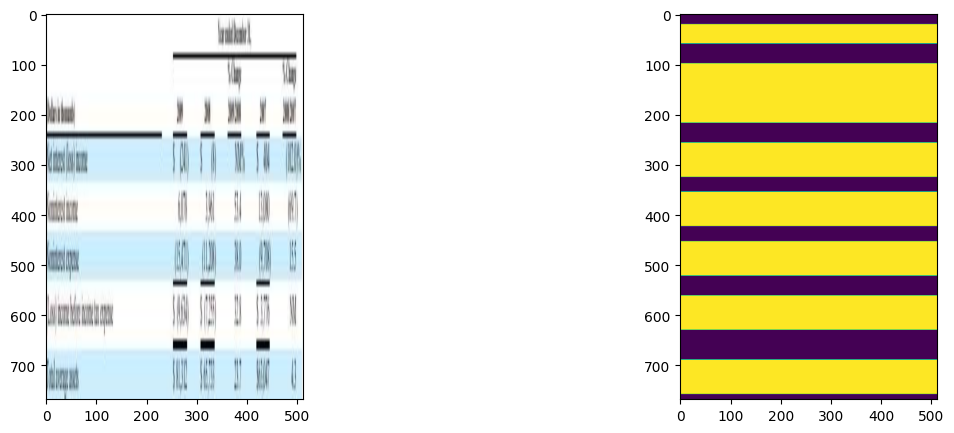

In [37]:
input_ , output_ = next(iter(data_loader))
test_image = input_['image'][0]

test_image =   test_image.permute(1,2,0)
test_image_np = np.array(test_image)

row_image = output_["row"][0]

row_image =   row_image.permute(1,2,0)
row_image_np = np.array(row_image)

fix ,ax = plt.subplots(1,2 ,figsize= (15,5))
ax[0].imshow(test_image_np)
ax[1].imshow(row_image_np)

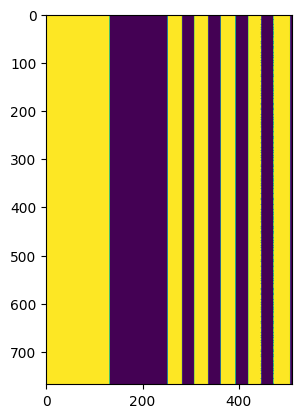

In [38]:
test_image = output_["col"][0]

test_image =   test_image.permute(1,2,0)
test_image_np = np.array(test_image)

plt.imshow(test_image_np)
plt.show()

In [39]:
def dice_loss(y_pred ,y_true, smooth=1e-5):
    y_pred = y_pred.view(-1)
    y_true = y_true.view(-1)
    intersection = torch.sum(y_true * y_pred).sum()
    # sum_of_squares_pred = torch.sum(torch.square(y_pred), dim=(1,2,3))
    # sum_of_squares_true = torch.sum(torch.square(y_true), dim=(1,2,3))
    dice = 1 - (2 * intersection + smooth) / (y_pred.sum() +  y_true.sum() + smooth)
    return dice

In [40]:
from tqdm import  tqdm

In [41]:
model_ = model_split()

model_.to(device)
# convert_rois_to_boxes = convert_rois_to_boxes.to(device)
optimizer = optim.AdamW(model_.parameters(), lr=0.00001, betas=(0.9, 0.999))

c:\Users\PC\miniconda3\envs\v1\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\PC\miniconda3\envs\v1\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
c:\Users\PC\miniconda3\envs\v1\lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [42]:
num_epochs = 10
loss_list  =[]
loss_row_list  =[]
loss_col_list = []
for epoch in range(num_epochs):
    for i, (inputs, gt) in tqdm(enumerate(data_loader)):
        # print(f'epoch :{epoch}, index {i}')
        # model_1.train(True)
        img_in = inputs['image']
        # bbox_in = inputs['bbox']

        row_gt = gt['row']
        row_gt = row_gt.float()
        # row_gt = row_gt.view(-1)
        col_gt = gt['col']
        col_gt = col_gt.float()
        # col_gt = col_gt.view(-1)
        img_in = img_in.to(device)
        if (torch.isnan(img_in).any()):
            print("error")
            continue

        row_gt = row_gt.to(device)
        col_gt = col_gt.to(device)
        optimizer.zero_grad()
        row_out, col_out = model_(img_in)

        row_loss = nn.BCELoss()(row_out, row_gt)
        col_loss = nn.BCELoss()(col_out, col_gt)
        bce_loss_total = row_loss  + col_loss

        row_dcie_loss = dice_loss(row_out, row_gt)
        col_dcie_loss = dice_loss(col_out, col_gt)
        dcie_loss_total = row_dcie_loss  + col_dcie_loss
        # print(dcie_loss_total)
        total_loss = 0.4*bce_loss_total + 0.6*dcie_loss_total
        total_loss.backward()
        # torch.nn.utils.clip_grad_norm_(model_.parameters(), 0.001)
        optimizer.step()


        loss_list.append(total_loss.item())
        loss_row_list.append(row_loss.item())
        loss_col_list.append(col_loss.item())
        del row_loss
        del col_loss
        del  total_loss
        del row_out
        del col_out
    loss_epoch = sum(loss_list)/len(loss_list)
    loss_row_epoch = sum(loss_row_list)/len(loss_row_list)
    loss_col_epoch = sum(loss_col_list)/len(loss_col_list)
    print(f'epoch:{epoch}============ loss: {loss_epoch}      loss row: {loss_row_epoch}      loss col :{loss_col_epoch}')
    loss_list.clear()
    loss_row_list.clear()
    loss_col_list.clear()  


0it [00:00, ?it/s]

x_H shape torch.Size([1, 32, 24, 128])
x_W shape torch.Size([1, 32, 192, 16])


1it [00:22, 22.95s/it]


epoch:0============ loss: 1.1636801958084106      loss row: 0.7633305191993713      loss col :0.704991340637207


0it [00:00, ?it/s]

...

epoch:5============ loss: 0.8885202407836914      loss row: 0.541714608669281      loss col :0.5355190634727478


0it [00:00, ?it/s]

x_H shape torch.Size([1, 32, 24, 128])
x_W shape torch.Size([1, 32, 192, 16])


0it [00:15, ?it/s]


KeyboardInterrupt: 